In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft

## EXPLORAÇÃO

In [77]:
df = pd.read_csv('accelerometer.csv')

df.sample(10)

,wconfid,pctid,x,y,z
109476,3,30,0.977,0.008,-0.160
126546,3,60,0.965,-0.016,-0.137
87889,2,80,0.828,0.340,0.098
40895,1,85,-1.289,-0.242,-0.102
17691,1,45,0.969,-0.406,-0.020
71579,2,50,1.086,-0.102,-0.066
100585,2,100,-3.301,1.945,1.742
76081,2,60,1.145,-0.406,-0.027
12548,1,40,1.004,-0.105,-0.059
99828,2,100,0.254,-1.234,-1.371


In [78]:
# wconfid = quanlitativo nominal
# pctid = quantitativo discreto
# x, y, z = quantitativo contínuo

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153000 entries, 0 to 152999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   wconfid  153000 non-null  int64  
 1   pctid    153000 non-null  int64  
 2   x        153000 non-null  float64
 3   y        153000 non-null  float64
 4   z        153000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 5.8 MB


In [80]:
df.describe()

,wconfid,pctid,x,y,z
count,153000.000000,153000.000000,153000.000000,153000.000000,153000.000000
mean,2.000000,60.000000,0.995622,0.005351,-0.117769
std,0.816499,24.494977,0.773958,0.742602,0.517008
min,1.000000,20.000000,-8.000000,-8.000000,-5.867000
25%,1.000000,40.000000,0.945000,-0.078000,-0.172000
50%,2.000000,60.000000,0.992000,0.008000,-0.125000
75%,3.000000,80.000000,1.039000,0.105000,-0.066000
max,3.000000,100.000000,7.996000,7.996000,6.086000


In [81]:
## DISTRIBUIÇÕES
# wconfid = simétrica
# pctid = simétrico
# x = simétrico
# y = um pouco disperso
# z = simétrico

In [82]:
# Ver quantidade de duplicatas
df.duplicated().sum()

# Ver as duplicatas
df[df.duplicated(keep=False)]

# Neste caso específico é normal manter as linhas duplicadas, já que se trata de dados de uma máquina de regime estável.

,wconfid,pctid,x,y,z
1,1,20,1.004,-0.043,-0.125
4,1,20,1.000,-0.016,-0.121
10,1,20,1.012,0.043,-0.133
12,1,20,0.988,-0.020,-0.125
13,1,20,1.012,0.043,-0.129
...,...,...,...,...,...
152475,3,100,1.000,0.215,-0.191
152552,3,100,1.172,-0.242,-0.207
152712,3,100,0.918,-0.012,-0.488
152774,3,100,0.824,0.012,-0.109


In [83]:
df['pctid'].unique()

array([ 20,  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,  75,  80,
        85,  90,  95, 100], dtype=int64)

<Axes: xlabel='pctid', ylabel='count'>

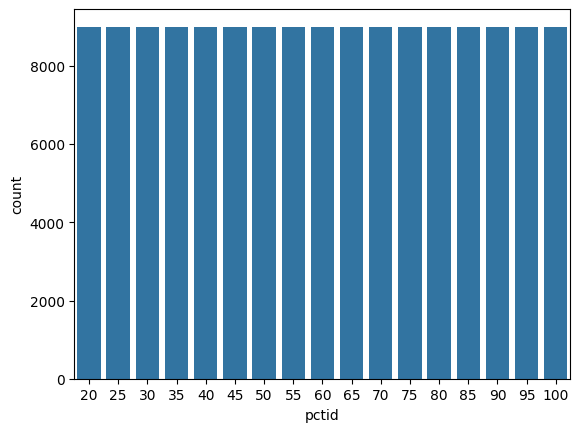

In [84]:
sns.countplot(data=df, x='pctid')

<Axes: xlabel='wconfid', ylabel='count'>

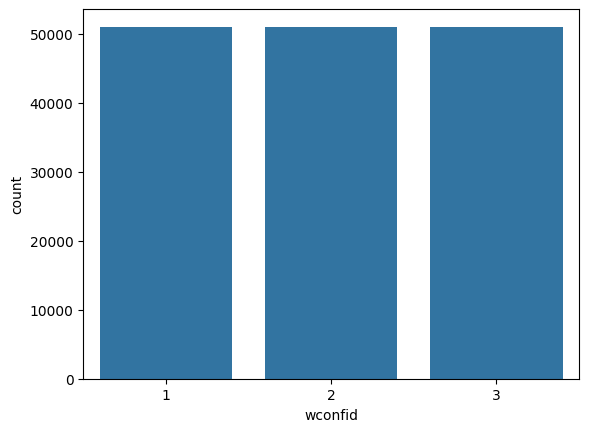

In [85]:
sns.countplot(data=df, x='wconfid')

In [86]:
# DISTRIBUIÇÃO NORMAL PARA WCONFID E PCTID

## ANÁLISE EXPLORATÓRIA

In [87]:
df['amp'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

df

,wconfid,pctid,x,y,z,amp
0,1,20,1.004,0.090,-0.125,1.015747
1,1,20,1.004,-0.043,-0.125,1.012665
2,1,20,0.969,0.090,-0.121,0.980664
3,1,20,0.973,-0.012,-0.137,0.982671
4,1,20,1.000,-0.016,-0.121,1.007421
...,...,...,...,...,...,...
152995,3,100,1.051,0.090,-0.262,1.086897
152996,3,100,0.918,0.039,-0.129,0.927839
152997,3,100,1.156,-0.094,-0.227,1.181821
152998,3,100,0.934,0.203,-0.172,0.971159


<Axes: xlabel='pctid', ylabel='amp'>

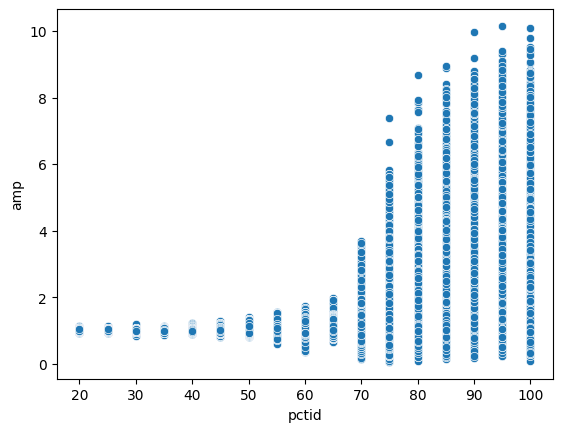

In [88]:
sns.scatterplot(data=df[df['wconfid'] == 1], x='pctid', y='amp')

<Axes: xlabel='pctid', ylabel='amp'>

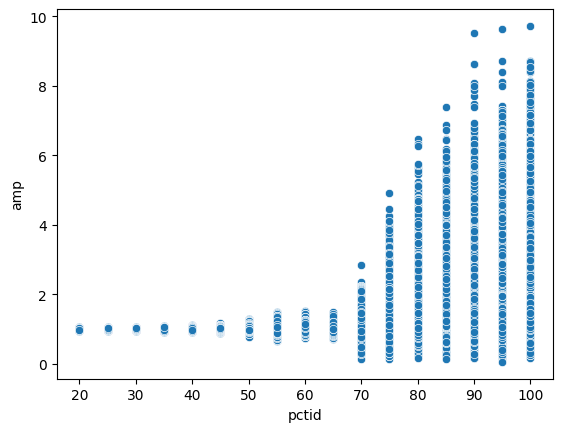

In [89]:
sns.scatterplot(data=df[df['wconfid'] == 2], x='pctid', y='amp')

<Axes: xlabel='pctid', ylabel='amp'>

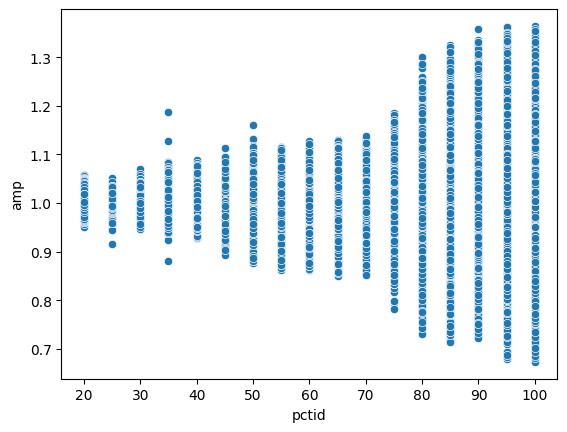

In [90]:
sns.scatterplot(data=df[df['wconfid'] == 3], x='pctid', y='amp')

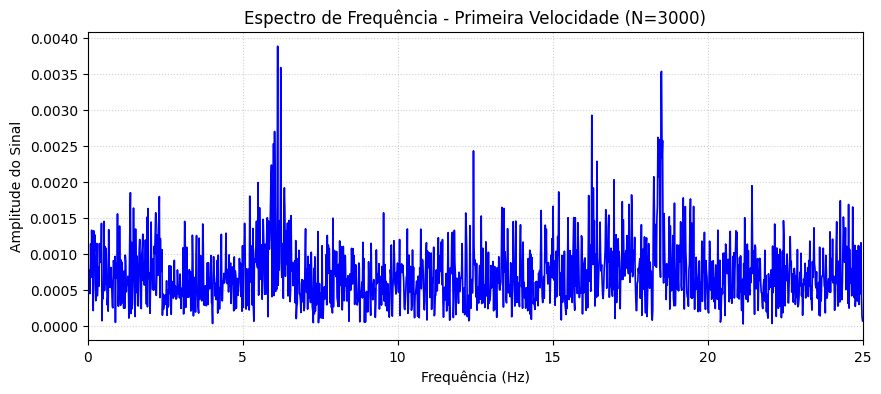

In [101]:
fs = 50.0  # 50 Hz (1 ponto a cada 20ms)

# 2. Separar apenas a primeira velocidade (primeiros 3000 pontos)
# Você também pode filtrar por: df[df['pctid'] == valor_da_velocidade]
dados_velocidade_1 = df[(df['wconfid'] == 1) & (df['pctid'] == 30)]['amp'].values

dados_velocidade_1 = dados_velocidade_1 - np.mean(dados_velocidade_1)
N = len(dados_velocidade_1)

# 3. Calcular a FFT para este bloco
fft_valores = np.fft.rfft(dados_velocidade_1)
frequencias = np.fft.rfftfreq(N, d=1/fs)

# Normalização da amplitude
amplitudes_frequencia = np.abs(fft_valores) * 2.0 / N
amplitudes_frequencia[0] = amplitudes_frequencia[0] / 2.0 

# 4. Plotar o gráfico de vibração real
plt.figure(figsize=(10, 4))
plt.plot(frequencias, amplitudes_frequencia, color='blue', linewidth=1.2)
plt.title(f"Espectro de Frequência - Primeira Velocidade (N={N})")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude do Sinal")
plt.xlim(0, 25)  # Limite de Nyquist para os seus 50Hz de amostragem
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

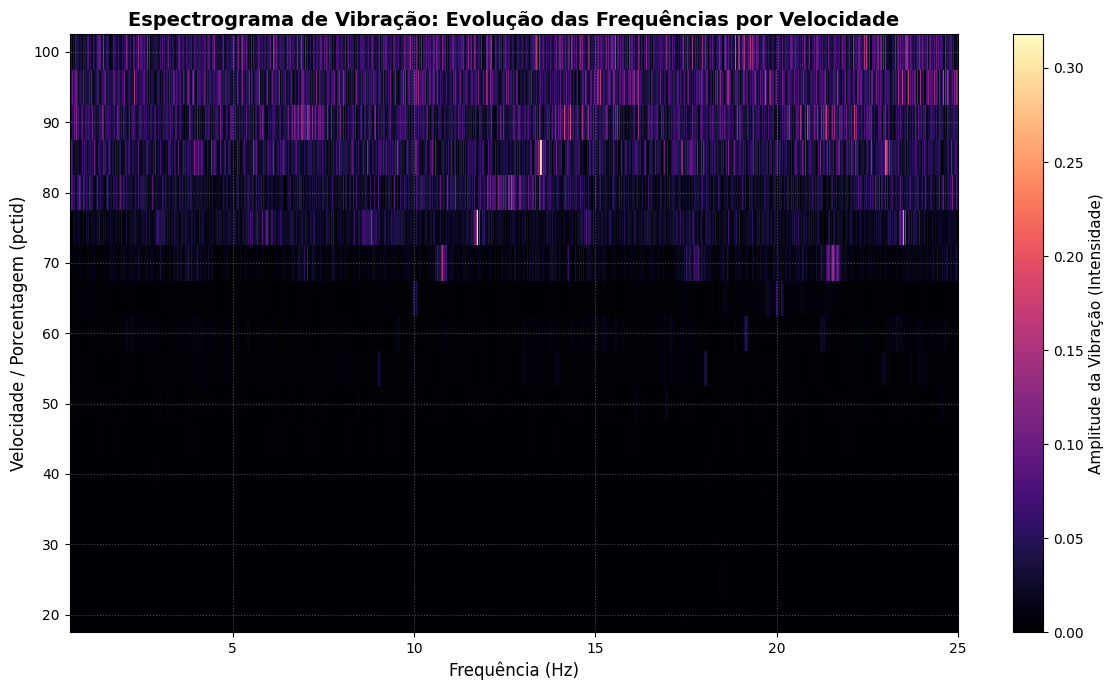

In [103]:
# Configurações físicas fixas do seu problema
fs = 50.0  # 50 Hz (1 ponto a cada 20ms)
N = 3000   # Número de pontos padrão por velocidade

# OPCIONAL: Se você quiser filtrar por uma configuração específica de 'wconfid'
df = df[df['wconfid'] == 1]

# 2. Descobrir todas as velocidades únicas de forma organizada (ex: 20, 30, 40...)
velocidades_unicas = sorted(df['pctid'].unique())

matriz_espectros = []
velocidades_plot = []

# 3. Loop automático para calcular a FFT de cada velocidade
for pct in velocidades_unicas:
    # Extrai apenas os dados daquela velocidade específica
    dados_velocidade = df[df['pctid'] == pct]['amp'].values
    
    # Pula se o bloco estiver vazio por algum motivo
    if len(dados_velocidade) == 0:
        continue
        
    # Remove a média (Componente DC) para não estragar a escala do gráfico
    dados_sem_dc = dados_velocidade - np.mean(dados_velocidade)
    
    # Calcula a FFT (forçando n=N para alinhar perfeitamente a matriz)
    fft_valores = np.fft.rfft(dados_sem_dc, n=N)
    
    # Normalização da amplitude
    amplitudes_frequencia = np.abs(fft_valores) * 2.0 / N
    amplitudes_frequencia[0] = amplitudes_frequencia[0] / 2.0 
    
    # Salva o espectro calculado e a velocidade correspondente
    matriz_espectros.append(amplitudes_frequencia)
    velocidades_plot.append(pct)

# Convertendo para arrays do NumPy
matriz_espectros = np.array(matriz_espectros)
frequencias = np.fft.rfftfreq(N, d=1/fs)

# 4. Construir o Mapa de Calor (Espectrograma)
plt.figure(figsize=(12, 7))

# Usamos o 'pcolormesh' que é ideal para eixos com valores reais (Hz e %)
# O mapa de cores 'magma' ou 'viridis' destaca muito bem os picos (tons claros = picos fortes)
mesh = plt.pcolormesh(frequencias, velocidades_plot, matriz_espectros, 
                      shading='auto', cmap='magma')

# Adiciona a barra lateral de cores para indicar a intensidade da amplitude
cbar = plt.colorbar(mesh)
cbar.set_label("Amplitude da Vibração (Intensidade)", fontsize=11)

# Customizações estéticas importantes do gráfico
plt.title("Espectrograma de Vibração: Evolução das Frequências por Velocidade", fontsize=14, fontweight='bold')
plt.xlabel("Frequência (Hz)", fontsize=12)
plt.ylabel("Velocidade / Porcentagem (pctid)", fontsize=12)

# Limitando o eixo X de 0.5 Hz até o limite de Nyquist (25 Hz)
plt.xlim(0.5, 25) 

# Adiciona linhas de grade sutis para ajudar na leitura
plt.grid(True, linestyle=':', alpha=0.3, color='white')

plt.tight_layout()
plt.show()

In [108]:
from sklearn.ensemble import IsolationForest
from scipy.stats import kurtosis
from sklearn.preprocessing import StandardScaler

# 1. FUNÇÃO PARA EXTRAIR FEATURES (Igual à anterior)
def extrair_features(sinal, fs=50.0):
    sinal_sem_dc = sinal - np.mean(sinal)
    rms = np.sqrt(np.mean(sinal_sem_dc**2))
    pico = np.max(np.abs(sinal_sem_dc))
    fator_crista = pico / rms if rms > 0 else 0
    curtose_val = kurtosis(sinal_sem_dc)
    
    N = len(sinal_sem_dc)
    fft_valores = np.fft.rfft(sinal_sem_dc, n=N)
    frequencias = np.fft.rfftfreq(N, d=1/fs)
    amplitudes = np.abs(fft_valores) * 2.0 / N
    
    idx_max = np.argmax(amplitudes)
    frequencia_pico = frequencias[idx_max]
    amplitude_pico = amplitudes[idx_max]
    
    # Mude a linha de retorno da sua função para isto:
    return [rms, amplitude_pico, frequencia_pico]

# 2. SEPARAÇÃO ESTRATÉGICA DOS DADOS
X_treino = []
X_teste_total = []
velocidades_total = sorted(df['pctid'].unique())

for pct in velocidades_total:
    dados_bloco = df[df['pctid'] == pct]['amp'].values
    if len(dados_bloco) >= 3000:
        sinal = dados_bloco[:3000]
        features = extrair_features(sinal)
        
        X_teste_total.append(features)
        
        # --- AQUI ESTÁ A MUDANÇA: O modelo SÓ estuda o que é NORMAL (20% a 60%) ---
        if pct <= 60:
            X_treino.append(features)

X_treino = np.array(X_treino)
X_teste_total = np.array(X_teste_total)

# 3. TREINAMENTO SEMISUPERVISIONADO
scaler = StandardScaler()
X_treino_escalado = scaler.fit_transform(X_treino)
X_teste_escalado = scaler.transform(X_teste_total)

# Treinar o modelo com os dados na mesma escala física
modelo_perfeito = IsolationForest(contamination=0.01, random_state=42)
modelo_perfeito.fit(X_treino_escalado) 

# Prever no dataset escalado
previsoes_finais = modelo_perfeito.predict(X_teste_escalado)

print("\n--- RESULTADO REAL E CALIBRADO ---")
for i, pct in enumerate(velocidades_total[:len(previsoes_finais)]):
    status = "NORMAL (Seguro)" if previsoes_finais[i] == 1 else "⚠️ ANOMALIA DETECTADA!"
    print(f"Velocidade {pct}% -> Status: {status}")


--- RESULTADO REAL E CALIBRADO ---
Velocidade 20% -> Status: NORMAL (Seguro)
Velocidade 25% -> Status: NORMAL (Seguro)
Velocidade 30% -> Status: NORMAL (Seguro)
Velocidade 35% -> Status: NORMAL (Seguro)
Velocidade 40% -> Status: NORMAL (Seguro)
Velocidade 45% -> Status: NORMAL (Seguro)
Velocidade 50% -> Status: NORMAL (Seguro)
Velocidade 55% -> Status: NORMAL (Seguro)
Velocidade 60% -> Status: ⚠️ ANOMALIA DETECTADA!
Velocidade 65% -> Status: ⚠️ ANOMALIA DETECTADA!
Velocidade 70% -> Status: ⚠️ ANOMALIA DETECTADA!
Velocidade 75% -> Status: ⚠️ ANOMALIA DETECTADA!
Velocidade 80% -> Status: ⚠️ ANOMALIA DETECTADA!
Velocidade 85% -> Status: ⚠️ ANOMALIA DETECTADA!
Velocidade 90% -> Status: ⚠️ ANOMALIA DETECTADA!
Velocidade 95% -> Status: ⚠️ ANOMALIA DETECTADA!
Velocidade 100% -> Status: NORMAL (Seguro)
